<a href="https://colab.research.google.com/github/ayesha-tubassum/Machine_Learning_algorithmns/blob/main/KNN(fraud_dataset).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Synthetic Fraud Detection using KNN Classifier**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, classification_report

# Set style for graphics
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv('synthetic_fraud_dataset.csv')
print("Dataset Loaded Successfully!")
print(f"Dataset Shape: {df.shape}")

Dataset Loaded Successfully!
Dataset Shape: (10000, 10)


In [3]:
df.head()

,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,9608,363,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
1,456,692,48.018303,QR,Food,US,21,0.168571,0.224057,0
2,4747,587,136.881960,Online,Travel,TR,14,0.296127,0.125058,0
3,6934,445,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0
4,1646,729,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     10000 non-null  int64  
 1   user_id            10000 non-null  int64  
 2   amount             10000 non-null  float64
 3   transaction_type   10000 non-null  object 
 4   merchant_category  10000 non-null  object 
 5   country            10000 non-null  object 
 6   hour               10000 non-null  int64  
 7   device_risk_score  10000 non-null  float64
 8   ip_risk_score      10000 non-null  float64
 9   is_fraud           10000 non-null  int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


/tmp/ipykernel_4672/2675434139.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_fraud', data=df, palette='Set2')


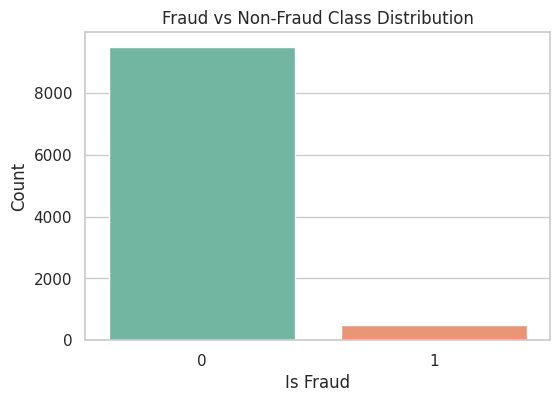

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x='is_fraud', data=df, palette='Set2')
plt.title('Fraud vs Non-Fraud Class Distribution')
plt.xlabel('Is Fraud')
plt.ylabel('Count')
plt.show()

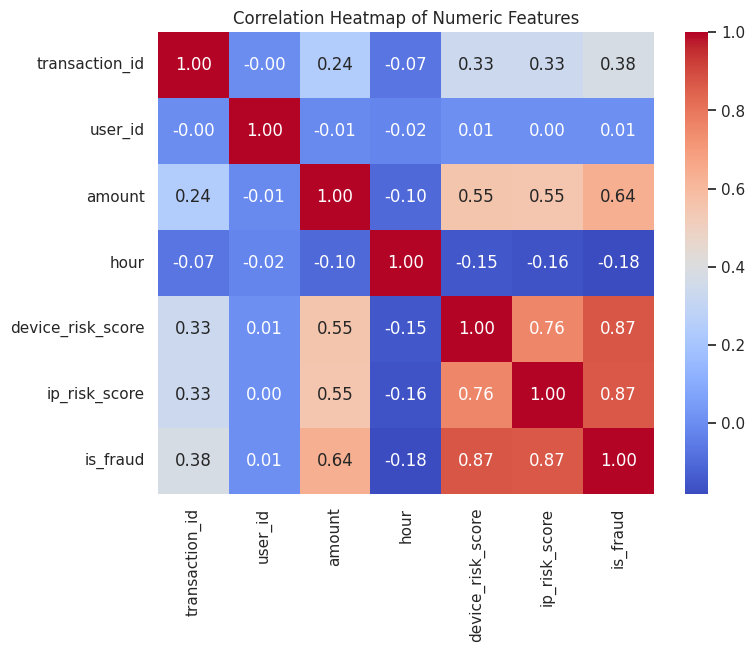

In [6]:
plt.figure(figsize=(8, 6))
# Selecting only numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

/tmp/ipykernel_4672/3884295063.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_fraud', y='amount', data=df, palette='Set1')


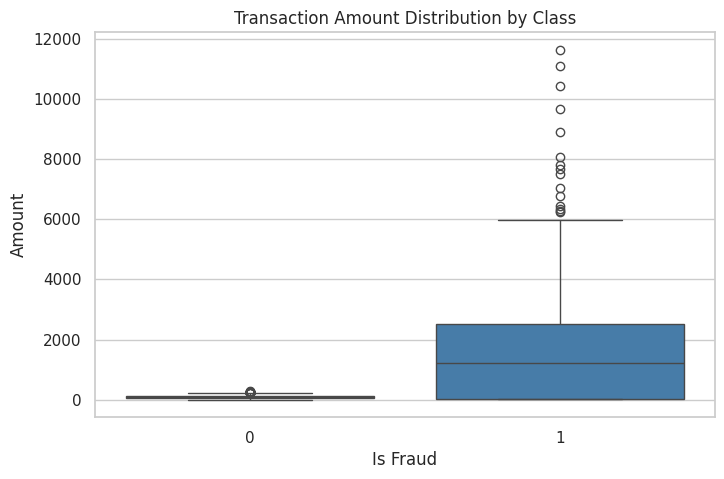

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='is_fraud', y='amount', data=df, palette='Set1')
plt.title('Transaction Amount Distribution by Class')
plt.xlabel('Is Fraud')
plt.ylabel('Amount')
plt.show()

In [8]:
# Dropping IDs as they do not provide predictive power
X = df.drop(columns=['transaction_id', 'user_id', 'is_fraud'])
y = df['is_fraud']

# Perform One-Hot Encoding on Categorical Features
X_encoded = pd.get_dummies(X, columns=['transaction_type', 'merchant_category', 'country'], drop_first=True)

print(f"Features shape after encoding: {X_encoded.shape}")
X_encoded.head()

Features shape after encoding: (10000, 16)


,amount,hour,device_risk_score,ip_risk_score,transaction_type_Online,transaction_type_POS,transaction_type_QR,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel,country_FR,country_NG,country_TR,country_UK,country_US
0,4922.587542,12,0.992347,0.947908,False,False,False,False,False,False,True,False,False,True,False,False
1,48.018303,21,0.168571,0.224057,False,False,True,False,True,False,False,False,False,False,False,True
2,136.881960,14,0.296127,0.125058,True,False,False,False,False,False,True,False,False,True,False,False
3,80.534719,23,0.124801,0.159243,False,True,False,False,False,False,False,False,False,True,False,False
4,120.041158,16,0.098129,0.027542,True,False,False,False,False,True,False,True,False,False,False,False


In [9]:
# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data splitting and scaling completed successfully.")

Data splitting and scaling completed successfully.


In [10]:
# Initialize the model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Fit the model on scaled training data
knn_model.fit(X_train_scaled, y_train)

print("KNN Classifier Trained successfully!")

KNN Classifier Trained successfully!


In [12]:
# Predictions on Test Data
y_pred = knn_model.predict(X_test_scaled)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN Accuracy Score: {accuracy * 100:.2f}%")

KNN Accuracy Score: 100.00%


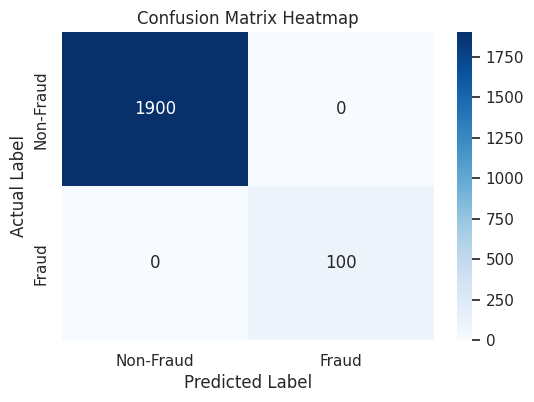

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Fraud', 'Fraud'],
            yticklabels=['Non-Fraud', 'Fraud'])
plt.ylabel('Actual Label')
print()
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [14]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1900
           1       1.00      1.00      1.00       100

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

